In [15]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in ["datapipeline", "model", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from datapipeline.config import (
    APPLICATION_CLEAN,
    BUREAU_CLEAN,
    APPLICATION_FEATURES,
    BUREAU_FEATURES,
    ABT_FILE,
)

print("Raiz do projeto:", PROJECT_ROOT)

Raiz do projeto: c:\Users\MegumiKa\Downloads\000.git\LABFIA_TCC\credix


Carregar bases

In [16]:
app_clean = pd.read_csv(APPLICATION_CLEAN)
bureau_clean = pd.read_csv(BUREAU_CLEAN)
app_features = pd.read_csv(APPLICATION_FEATURES)
bureau_features = pd.read_csv(BUREAU_FEATURES)
abt = pd.read_csv(ABT_FILE)

print("Application clean:", app_clean.shape)
print("Bureau clean:", bureau_clean.shape)
print("Application features:", app_features.shape)
print("Bureau features:", bureau_features.shape)
print("ABT:", abt.shape)

abt.head()

Application clean: (307511, 122)
Bureau clean: (1716428, 17)
Application features: (307511, 16)
Bureau features: (305811, 6)
ABT: (307511, 21)


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,IDADE,TEMPO_EMPRESA,...,PARCELA_RENDA,BEM_RENDA,RENDA_LIVRE,COMPROMETIMENTO_RENDA,PRAZO_ESTIMADO,BUREAU_QTD_CREDITOS,BUREAU_QTD_ATIVOS,BUREAU_TOTAL_CREDITO,BUREAU_TOTAL_DIVIDA,BUREAU_DEBT_RATIO
0,100002,1,202500.0,406597.5,24700.5,351000.0,Secondary / secondary special,Single / not married,25.92,1.75,...,0.12,1.73,177799.5,0.12,16.46,8.0,2.0,865055.565,245781.0,0.284122
1,100003,0,270000.0,1293502.5,35698.5,1129500.0,Higher education,Married,45.93,3.25,...,0.13,4.18,234301.5,0.13,36.23,4.0,1.0,1017400.500,0.0,0.000000
2,100004,0,67500.0,135000.0,6750.0,135000.0,Secondary / secondary special,Single / not married,52.18,0.62,...,0.10,2.00,60750.0,0.10,20.00,2.0,0.0,189037.800,0.0,0.000000
3,100006,0,135000.0,312682.5,29686.5,297000.0,Secondary / secondary special,Civil marriage,52.07,8.33,...,0.22,2.20,105313.5,0.22,10.53,0.0,0.0,0.000,0.0,0.000000
4,100007,0,121500.0,513000.0,21865.5,513000.0,Secondary / secondary special,Single / not married,54.61,8.32,...,0.18,4.22,99634.5,0.18,23.46,1.0,0.0,146250.000,0.0,0.000000


Distribuição do TARGET

In [17]:
target_abs = abt["TARGET"].value_counts().sort_index()
target_pct = abt["TARGET"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame(
    {
        "quantidade": target_abs,
        "percentual": target_pct.round(2),
    }
)

target_summary

,quantidade,percentual
TARGET,,
0,282686,91.93
1,24825,8.07


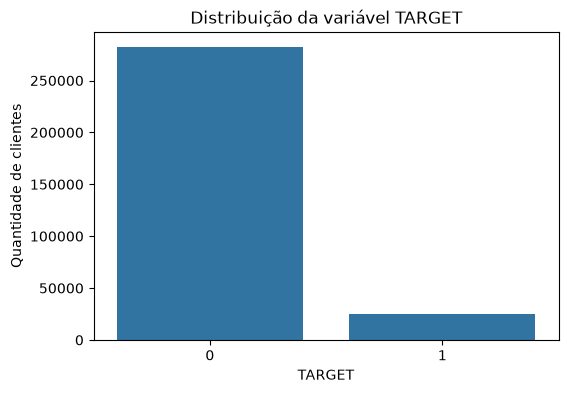

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=abt, x="TARGET")
plt.title("Distribuição da variável TARGET")
plt.xlabel("TARGET")
plt.ylabel("Quantidade de clientes")
plt.show()

A base apresenta forte desbalanceamento entre clientes adimplentes e inadimplentes. Esse ponto é importante porque influencia diretamente métricas como recall, precision e matriz de confusão.

Valores ausentes

In [19]:
missing = abt.isna().mean().sort_values(ascending=False) * 100

missing_df = missing.reset_index()
missing_df.columns = ["variavel", "percentual_nulos"]

missing_df.head(20)

,variavel,percentual_nulos
0,AMT_GOODS_PRICE,0.090403
1,RENDA_LIVRE,0.003902
2,AMT_ANNUITY,0.003902
3,SK_ID_CURR,0.000000
4,TARGET,0.000000
5,AMT_CREDIT,0.000000
6,AMT_INCOME_TOTAL,0.000000
7,NAME_FAMILY_STATUS,0.000000
8,NAME_EDUCATION_TYPE,0.000000
9,TEMPO_EMPRESA,0.000000


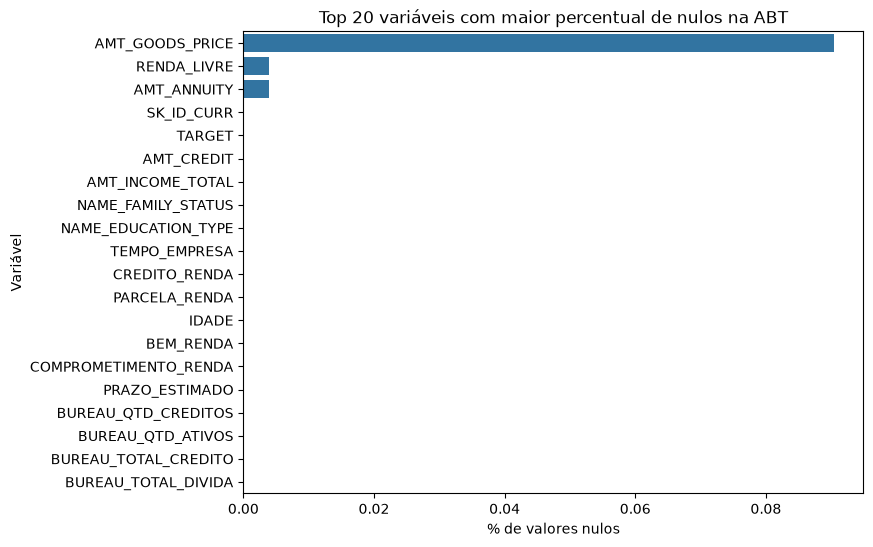

In [20]:
top_missing = missing_df.head(20)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_missing, x="percentual_nulos", y="variavel")
plt.title("Top 20 variáveis com maior percentual de nulos na ABT")
plt.xlabel("% de valores nulos")
plt.ylabel("Variável")
plt.show()

Variáveis numéricas principais

In [21]:
numeric_vars = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "IDADE",
    "TEMPO_EMPRESA",
    "CREDITO_RENDA",
    "PARCELA_RENDA",
    "COMPROMETIMENTO_RENDA",
    "BUREAU_DEBT_RATIO",
]

abt[numeric_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00,112500.00,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00,270000.00,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50,16524.00,24903.000000,34596.000000,2.580255e+05
IDADE,307511.0,43.936976,11.956135,20.52,34.01,43.150000,53.920000,6.912000e+01
TEMPO_EMPRESA,307511.0,5.355752,6.320730,0.00,0.79,3.320000,7.560000,4.907000e+01
CREDITO_RENDA,307511.0,3.957585,2.689684,0.00,2.02,3.270000,5.160000,8.474000e+01
PARCELA_RENDA,307511.0,0.180941,0.094600,0.00,0.11,0.160000,0.230000,1.880000e+00
COMPROMETIMENTO_RENDA,307511.0,0.180941,0.094600,0.00,0.11,0.160000,0.230000,1.880000e+00
BUREAU_DEBT_RATIO,307511.0,9.437866,4086.544495,0.00,0.00,0.120213,0.430939,2.250000e+06


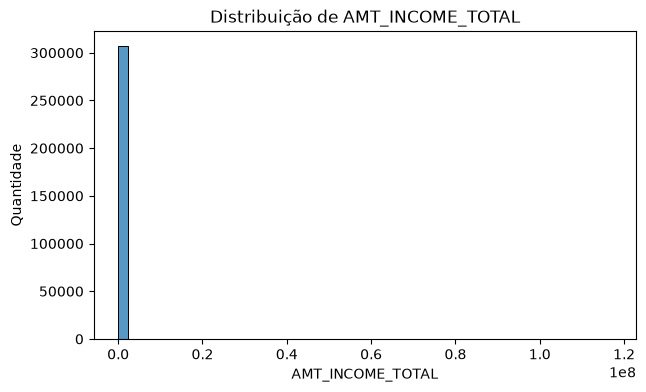

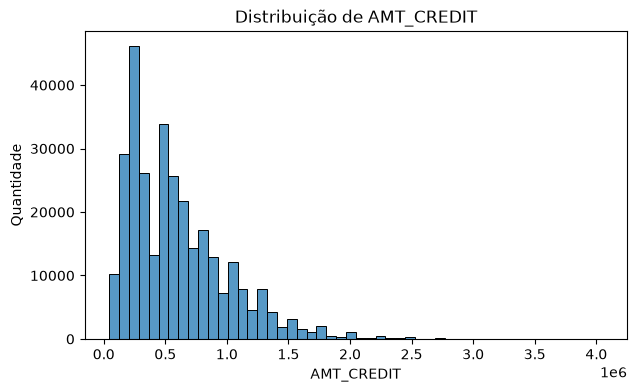

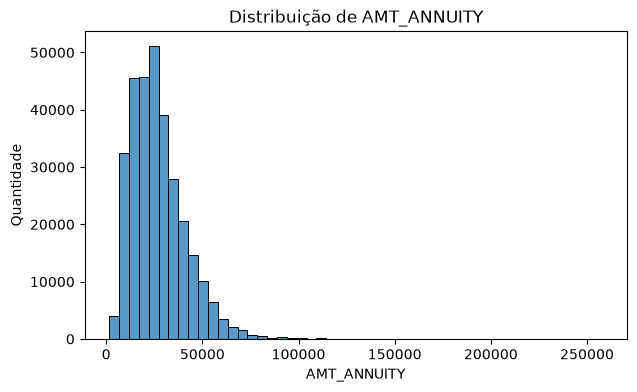

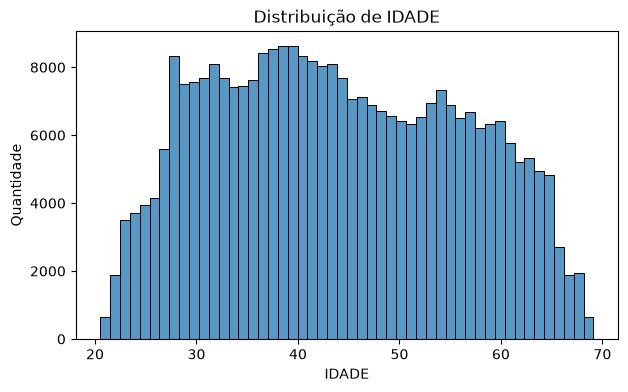

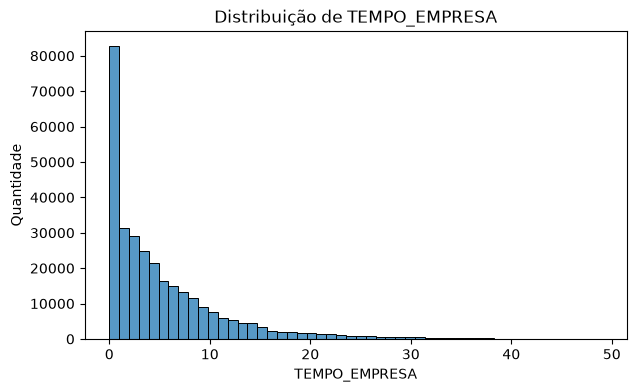

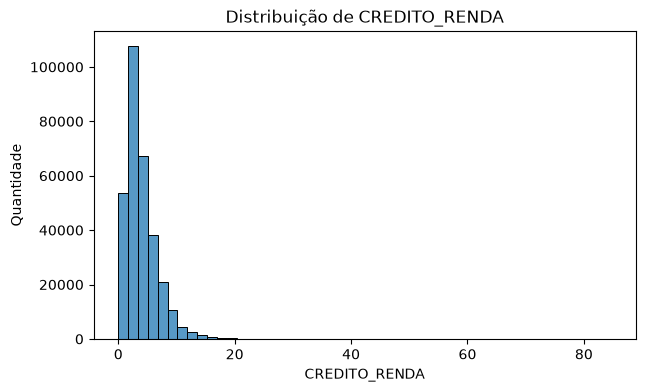

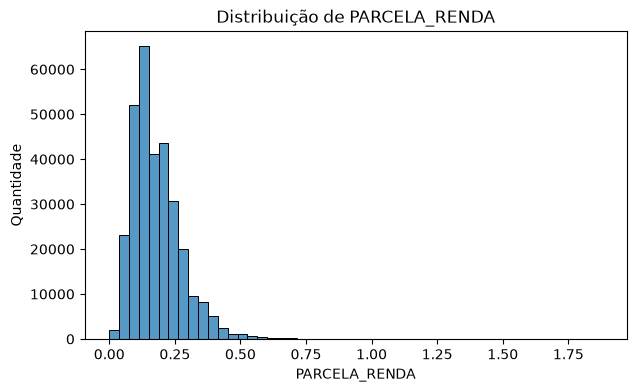

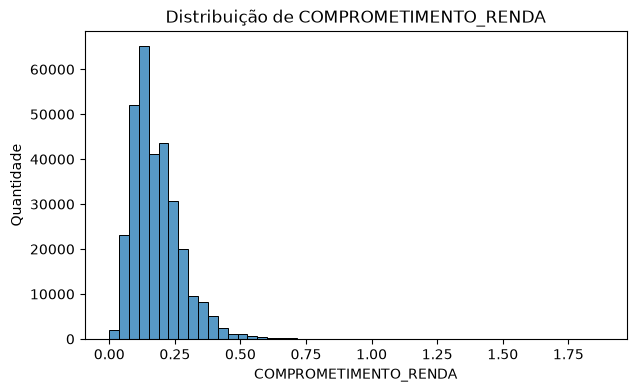

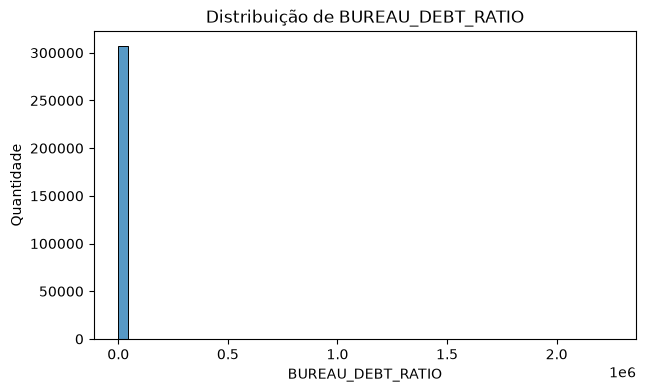

In [22]:
for col in numeric_vars:
    plt.figure(figsize=(7, 4))
    sns.histplot(abt[col], bins=50, kde=False)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Quantidade")
    plt.show()

As variáveis financeiras apresentam assimetria à direita, comportamento comum em bases de crédito, pois uma pequena parcela de clientes concentra valores mais altos de renda, crédito ou dívida.

Comparação por TARGET

In [23]:
compare_vars = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "IDADE",
    "TEMPO_EMPRESA",
    "COMPROMETIMENTO_RENDA",
    "BUREAU_DEBT_RATIO",
]

abt.groupby("TARGET")[compare_vars].median().T

TARGET,0,1
AMT_INCOME_TOTAL,148500.000000,135000.000000
AMT_CREDIT,517788.000000,497520.000000
IDADE,43.500000,39.130000
TEMPO_EMPRESA,3.380000,2.830000
COMPROMETIMENTO_RENDA,0.160000,0.170000
BUREAU_DEBT_RATIO,0.113154,0.221113


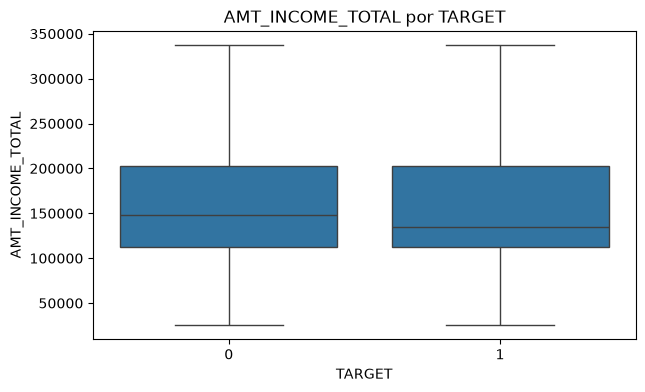

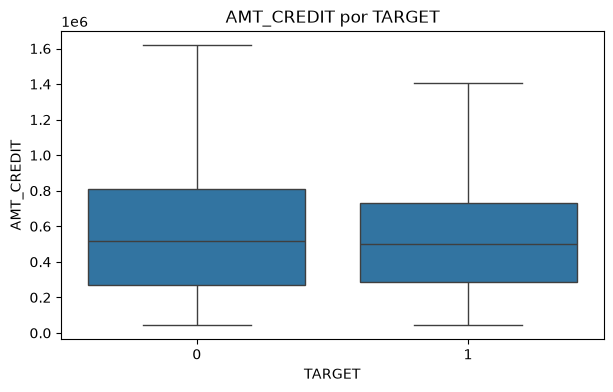

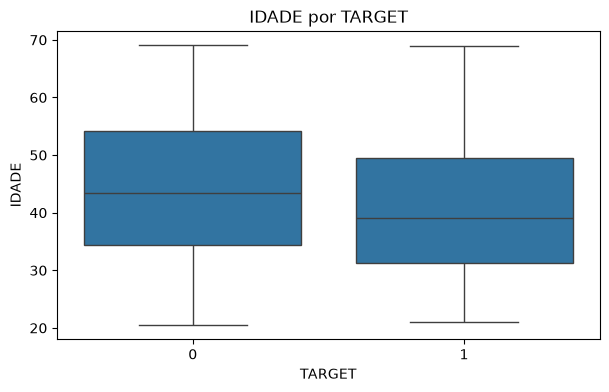

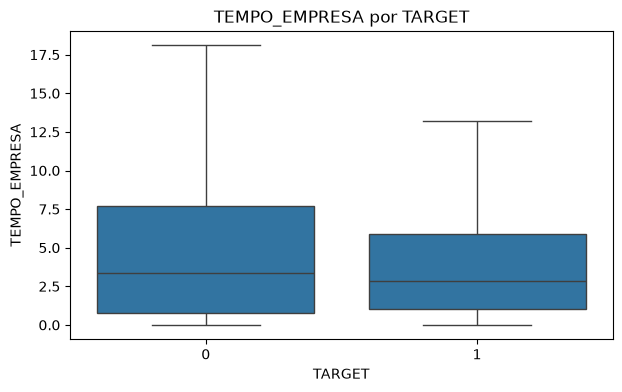

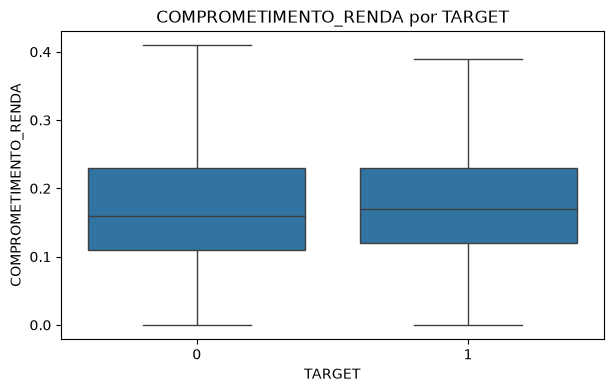

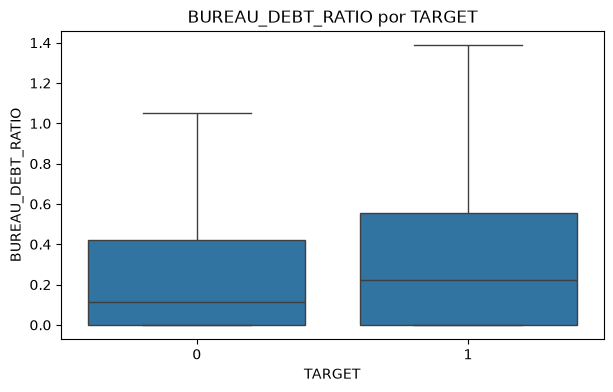

In [24]:
for col in compare_vars:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=abt, x="TARGET", y=col, showfliers=False)
    plt.title(f"{col} por TARGET")
    plt.xlabel("TARGET")
    plt.ylabel(col)
    plt.show()

Categóricas

In [25]:
cat_vars = ["NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]

for col in cat_vars:
    display(
        abt.groupby(col)["TARGET"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
        .rename(columns={"count": "quantidade", "mean": "taxa_inadimplencia"})
    )

,quantidade,taxa_inadimplencia
NAME_EDUCATION_TYPE,,
Lower secondary,3816,0.109277
Secondary / secondary special,218391,0.089399
Incomplete higher,10277,0.084850
Higher education,74863,0.053551
Academic degree,164,0.018293


,quantidade,taxa_inadimplencia
NAME_FAMILY_STATUS,,
Civil marriage,29775,0.099446
Single / not married,45444,0.098077
Separated,19770,0.081942
Married,196432,0.075599
Widow,16088,0.058242
Unknown,2,0.000000


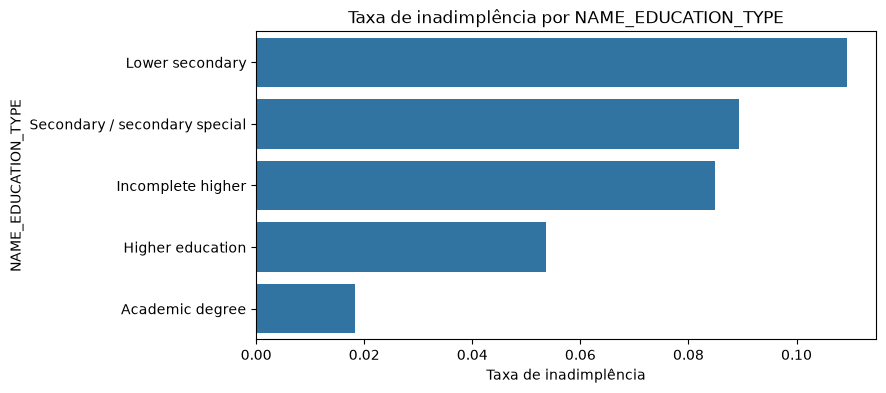

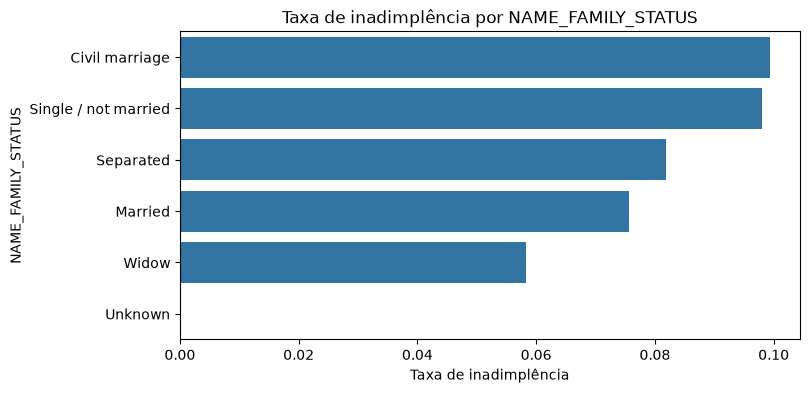

In [26]:
for col in cat_vars:
    rate = (
        abt.groupby(col)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=rate, x="TARGET", y=col)
    plt.title(f"Taxa de inadimplência por {col}")
    plt.xlabel("Taxa de inadimplência")
    plt.ylabel(col)
    plt.show()

Correlação

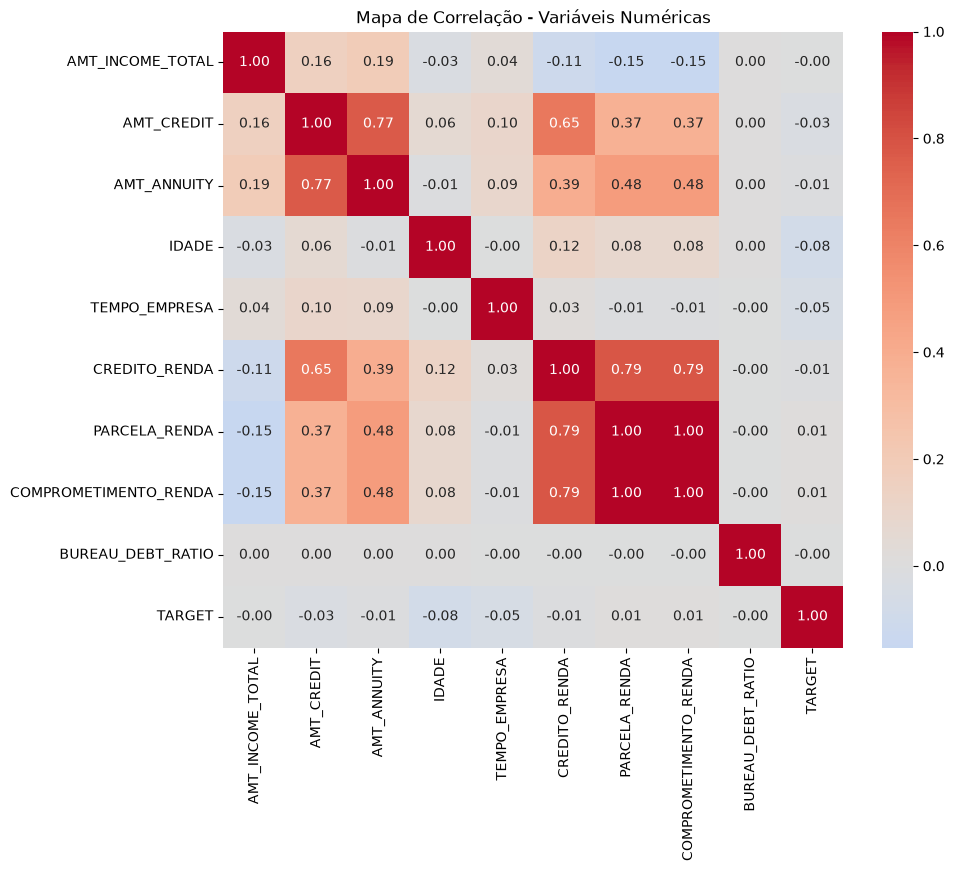

In [27]:
corr_vars = numeric_vars + ["TARGET"]

corr = abt[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de Correlação - Variáveis Numéricas")
plt.show()

A matriz de correlação permite avaliar relações lineares entre as variáveis. Correlação baixa com o TARGET não significa ausência de valor preditivo, especialmente porque modelos como XGBoost capturam relações não lineares.

Relação crédito, renda e bureau

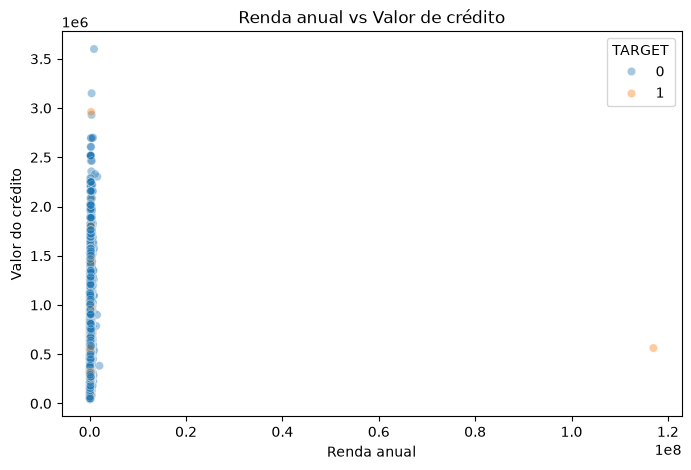

In [28]:
sample = abt.sample(min(10000, len(abt)), random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample,
    x="AMT_INCOME_TOTAL",
    y="AMT_CREDIT",
    hue="TARGET",
    alpha=0.4,
)
plt.title("Renda anual vs Valor de crédito")
plt.xlabel("Renda anual")
plt.ylabel("Valor do crédito")
plt.show()

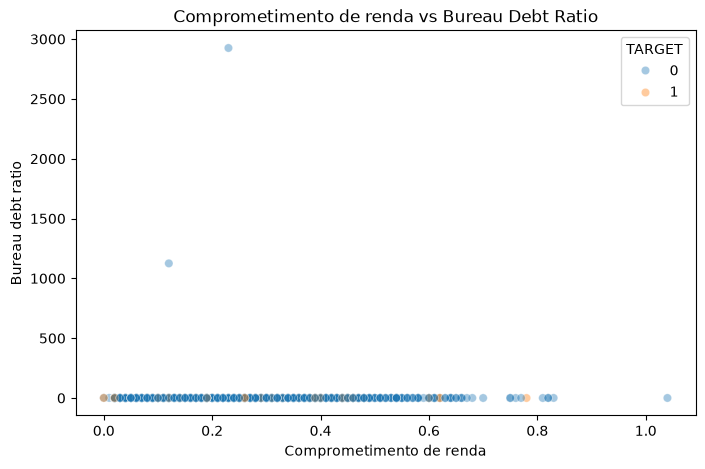

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample,
    x="COMPROMETIMENTO_RENDA",
    y="BUREAU_DEBT_RATIO",
    hue="TARGET",
    alpha=0.4,
)
plt.title("Comprometimento de renda vs Bureau Debt Ratio")
plt.xlabel("Comprometimento de renda")
plt.ylabel("Bureau debt ratio")
plt.show()

## Principais insights da EDA

1. A base possui forte desbalanceamento da variável alvo, com proporção menor de clientes inadimplentes.

2. As variáveis financeiras apresentam assimetria e presença de valores extremos, comportamento esperado em bases de crédito.

3. Variáveis como idade, tempo de empresa, comprometimento de renda e indicadores de bureau apresentam relevância conceitual para risco de crédito.

4. A base bureau agrega informações importantes sobre histórico de crédito, como quantidade de créditos ativos e relação dívida/crédito.

5. A ABT final consolida informações financeiras, cadastrais e de histórico externo em uma visão única por cliente.

## Conclusão

A análise exploratória demonstrou que o problema possui características típicas de risco de crédito: target desbalanceado, variáveis financeiras assimétricas e necessidade de combinar informações cadastrais com histórico de crédito.

Esses achados justificam a construção de uma ABT consolidada e o uso de um modelo robusto para dados tabulares, como o XGBoost.